<a href="https://colab.research.google.com/github/eogks1235-byte/DEEP_Learning-feat.Jake-Oh/blob/main/ml17_ann_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST 데이터셋 이미지 분류

# IMPORT

In [83]:
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

import numpy as np


In [84]:
tf.__version__

'2.19.0'

In [85]:
keras.__version__

'3.13.2'

In [86]:
print(tf.config.list_physical_devices())
# list를 보여주세요 물리적디바이스 나열한것을
# 코랩 환경상태
# CPU/GPU/TPU 사용 여부 확인

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [87]:
print(keras.config.backend()) # keras 라이브러리에서 텐서 연산을 할 때 필요한 라이브러리.

tensorflow


keras 라이브러리는 GPU 연산을 직접 수행하지 않음. 대신에 GPU 연산을 수행하는 다른 딥러닝 라이브러리를 백엔드(backend)로 활용함.

* Keras에서 사용하는 백엔드 종류
  * TensorFlow - 구글에서 만든 텐서 연산 라이브러리
  * PyTorch - 메타에서 만든 딥러닝 라이브러리 -> 리눅스 재단으로 이전, 오픈소스로 공개됨.
* Keras
  * 여러가지 백엔드를 사용해서 신경망을 쉽게 만들고 훈련할 수 있도록 만든 고급 라이브러리.
  * 2.3.1버전 이후부터는 TensorFlow만 단일 백엔드로 사용하도록 기능 변경.
  * 3.0 버전부터 다시 멀티 백엔드 정책으로 바뀜.  

# Fashion NMIST 데이터 셋

10개 클래스(ex: 바지, 셔츠, 구두, ...)의 패션 아이템 이미지 28x28 크기의 흑백 이미지. 60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [88]:
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

In [89]:
x_train.shape # (n_samples, width, height)

(60000, 28, 28)

In [90]:
y_train.shape # (n_samples, , )

(60000,)

In [91]:
x_test.shape

(10000, 28, 28)

In [92]:
y_test.shape

(10000,)

In [93]:
# 훈련 레이블의 중복되지 않는 값들 갯수
np.unique(y_train, return_counts=True) # 각 배열당 6000개씩 가지고 있다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [94]:
# 테스트 레이블의 중복되지 않는 값들
np.unique(y_test, return_counts=True) # 각 배열당 1000개씩 가지고 있다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

훈련 셋과 테스트 셋 모두 각 클래스의 샘플들이 같은 개수로 수집되어 있음.


In [95]:
x_train[0] #> 0~255 scale의 28x28 크기의 흑백 이미지

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

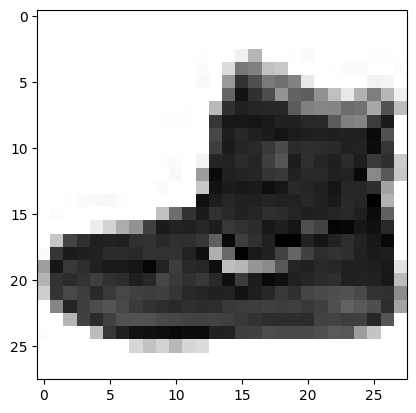

In [96]:
plt.imshow(x_train[0], cmap=plt.cm.binary) # plt.cm.gray
plt.show()

In [97]:
def plot_fastion_nmist(arr, ncols=10):
  # arr:(n_samples, width, height) shape의 3차원 배열
  # ncols: subplot axis의 컬럼 개수.
  n = len(arr) # 출력할 이미지 개수.
  nrows = int(np.ceil(n/ncols)) # supplot axis의 행 개수
  fig, axes = plt.subplots(nrows, ncols, figsize=(ncols,nrows))
  for i in range(nrows):
    for j in range(ncols):
      idx = i*ncols+j # 배열 arr에서 선택할 이미지의 인덱스
      if nrows==1 or ncols ==1: # axes는 1차원 배열
        if idx <n:
          axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
        axes[idx].axis('off')
      else: # axes는 2차원 배열
        if idx <n:
          axes[i,j].imshow(arr[idx],cmap=plt.cm.binary)
        axes[i,j].axis('off')
  plt.show()

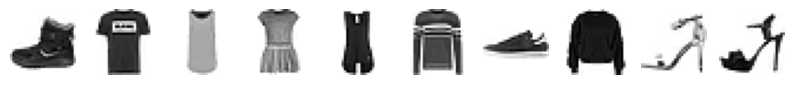

In [98]:
plot_fastion_nmist(x_train[:10])
#

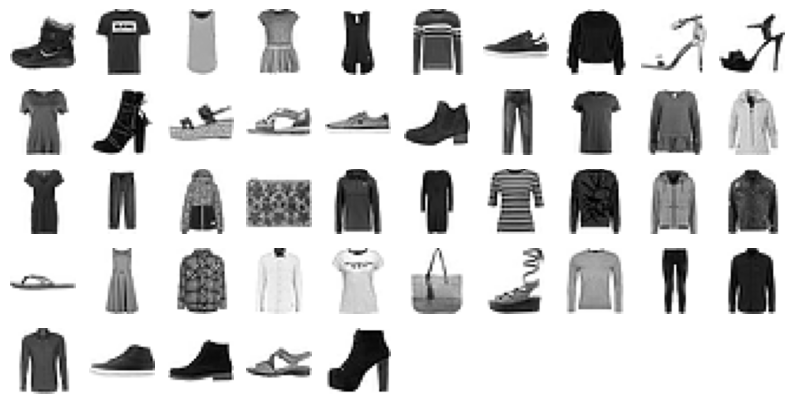

In [99]:
plot_fastion_nmist(x_train[:45])
#

# 훈련 셋 스케일, 훈련/검증 분리

In [100]:
# 훈련 셋의 스케일을 0~1 사이의 값으로 변경. -> SGDClassifier의 성능 향상을 위해 스케일링을 진행.
x_train_scaled  = x_train/255

In [101]:
# 훈련 셋과 훈련 레이블을 훈련/검증으로 분리
train_input, val_input, train_target, val_target= train_test_split(x_train_scaled, y_train,
                                                                   test_size=0.2, random_state=42,
                                                                   stratify=y_train)

In [102]:
train_input.shape

(48000, 28, 28)

In [103]:
train_target.shape

(48000,)

# SGD Classifier

In [104]:
# 모델 생성
sgd=SGDClassifier(loss='log_loss', random_state=42,n_jobs=-1) # log_loss : 확률계산


In [105]:
# 모델 훈련
# sgd.fit(X=train_input,y=train_target) # 사이킷런 3차원 이상 불가 2차원 배열이용해야한다
sgd.fit(X=train_input.reshape((48_000,-1)),y=train_target)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [106]:
sgd.coef_.shape

(10, 784)

In [107]:
sgd.coef_

array([[-7.70603663e-04,  2.72508248e-03, -3.00035463e-03, ...,
        -1.17690620e-01, -1.32566646e-01,  1.00472625e-02],
       [-2.48479624e-05,  9.32783836e-04, -2.03729836e-03, ...,
        -4.20798291e-02,  5.03346995e-02, -9.55232307e-03],
       [-3.55408691e-04,  2.15568460e-03, -2.11453328e-02, ...,
         7.36715033e-01,  3.44064688e-01,  1.03963915e-01],
       ...,
       [-8.99306976e-09, -4.83423496e-07, -3.95766709e-05, ...,
        -1.48104337e-02,  3.42542873e-02, -5.40338988e-03],
       [-2.42874708e-03,  1.30332774e-03, -3.62625491e-03, ...,
        -4.74249056e-01, -4.00274810e-01, -7.60014557e-02],
       [-3.16320637e-06,  2.96615865e-04,  2.48651463e-04, ...,
        -2.39997785e-01,  3.66218352e-01,  6.55158673e-02]])

In [108]:
sgd.intercept_.shape

(10,)

In [109]:
sgd.intercept_

array([ -1.54024535,  -4.97085256,  -2.45411884,  -1.5496291 ,
        -4.94592029,   3.66151889,  -1.47955462,  -1.90241534,
        -4.40078057, -25.19876253])

In [110]:
# 각 클래스가 될 확률
predict_probs = sgd.predict_proba(X=train_input.reshape((48_000,-1)))

In [111]:
predicts = sgd.predict(X=train_input.reshape((48_000,-1)))

In [112]:
predicts[:2]

array([6, 0], dtype=uint8)

In [113]:
accuracy_score(y_true=train_target, y_pred=predicts) # 훈련 셋 정확도

0.8518125

In [114]:
# 검증 셋 평가
val_input_2d= val_input.reshape((12_000,-1)) # 3d 배열 -> 2d 배열
val_predicts =sgd.predict(X=val_input_2d) # 검증 셋 예측값
accuracy_score(y_true=val_target, y_pred=val_predicts) # 검증 셋 정확도
#

0.8468333333333333

# 입력층과 출력층만 갖는 신경망

In [115]:
train_input_2d=train_input.reshape((48_000,-1))

In [116]:
train_input_2d.shape

(48000, 784)

In [117]:
# 입력층(input layer)
inputs=keras.Input(shape=(784,))

In [118]:
# 출력층(output layer)
dense=keras.layers.Dense(units=10,activation='softmax')

In [119]:
# 완전 연결 신경망
model=keras.Sequential(layers=[inputs,dense])

In [120]:
model.summary()
# 784* 10 +10

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_crossentropy])

In [122]:
# 신경망 모델 훈련
model.fit(x=train_input_2d, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0393 - sparse_categorical_crossentropy: 1.0393
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7112 - sparse_categorical_crossentropy: 0.7112
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6390 - sparse_categorical_crossentropy: 0.6390
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5993 - sparse_categorical_crossentropy: 0.5993
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5736 - sparse_categorical_crossentropy: 0.5736
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5544 - sparse_categorical_crossentropy: 0.5544
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5400 - sparse_categorical_crossentropy: 0.5400
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5282 - sparse_categorical_crossentropy: 0.5282
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5190 - sparse_categorical_crossentropy: 0.5190
Epoch 10/10
750/750

In [123]:
# 훈련된 신경망 모델이 찾은 모델 파라미터들(가중치, weights)
model.weights # kernel, bias

[<Variable path=sequential_1/dense_1/kernel, shape=(784, 10), dtype=float32, value=[[-0.0401299   0.00743205 -0.04301206 ... -0.04750089 -0.05225165
    0.06646994]
  [-0.02134825  0.05073022  0.08531579 ... -0.05510025  0.05931832
    0.07261013]
  [ 0.0527683   0.07751089  0.02158582 ... -0.01141259  0.08045293
    0.05138008]
  ...
  [-0.06776049  0.06705177  0.04773736 ...  0.06781153  0.02257168
   -0.01700204]
  [ 0.0707878  -0.0470297   0.04987062 ...  0.05663845 -0.01683441
   -0.01052763]
  [-0.08517478  0.00505343 -0.07366008 ...  0.07031994  0.02851371
    0.00808315]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(10,), dtype=float32, value=[ 0.09453032 -0.08727472 -0.09575558  0.00223326 -0.45573124  1.1473223
   0.22387385 -0.10060629 -0.25283402 -0.47575578]>]

In [124]:
predicts =model.predict(x=train_input_2d)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [125]:
predicts.shape #> (48,000, 10) = (n_samples, n_classes)

(48000, 10)

In [126]:
predicts[:2]

array([[7.05088209e-03, 5.10338868e-04, 2.58860111e-01, 1.53820757e-02,
        6.70520812e-02, 4.16286566e-05, 6.44191861e-01, 1.69999726e-06,
        6.89649349e-03, 1.28580705e-05],
       [5.78957140e-01, 3.31092917e-04, 2.61046621e-03, 1.04908543e-02,
        1.67532414e-02, 1.97985727e-07, 3.90360087e-01, 3.72686117e-07,
        4.94017440e-04, 2.55984583e-06]], dtype=float32)

In [127]:
# 훈련 셋의 예측 레이블 계산 - 10개의 확률들 중 최댓값의 인덱스.
train_pred_labels =  predicts.argmax(axis=1)

In [128]:
train_pred_labels[:2]

array([6, 0])

In [129]:
accuracy_score(y_true=train_target,y_pred=train_pred_labels)
# 훈련 셋 정확도

0.8328958333333333

In [130]:
model.evaluate(x=train_input_2d, y=train_target)
# loss , accuracy

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5057 - sparse_categorical_crossentropy: 0.5057


[0.5057442784309387, 0.5057442784309387]

In [135]:
# 검증 셋 정확도
model.evaluate(x=val_input_2d, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4970 - sparse_categorical_crossentropy: 0.4970


[0.49702662229537964, 0.49702662229537964]

# 활성화 함수(Activation Function)

* 활성화 함수: 신경망의 각 층(layer)에서 출력을 내보내는 함수.
* 은닉측(hidden layer)에서 활성화 함수로 선형 함수를 사용하면 여러 개의 층을 연결하는 효과가 없음.
  * 단일 층을 사용하는 것과 같음.
* 은닉측에서는 비선형 함수를 활성화 함수로 사용.  

## Sigmoid 함수

$
\text{sigmoid}(x) = \dfrac{1}{1 + \exp(-x)}
$



In [136]:
xvals=np.arange(-5,5,0.0001)

In [137]:
def sigmoid(x):
  return 1/(1+ np.exp(-x))

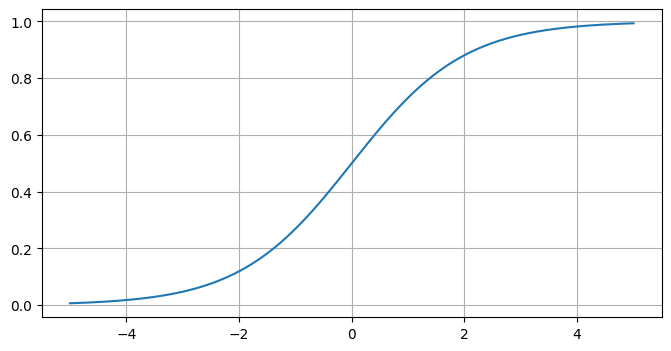

In [139]:
plt.figure(figsize=(8,4))
plt.plot(xvals, sigmoid(xvals))
plt.grid()
plt.show()

In [144]:
def plot_activation_fn(fn):
  xvals=np.arange(-5,5,0.0001)
  yvals=fn(xvals)
  plt.figure(figsize=(8,4))
  plt.plot(xvals, yvals)
  plt.grid()
  plt.show()

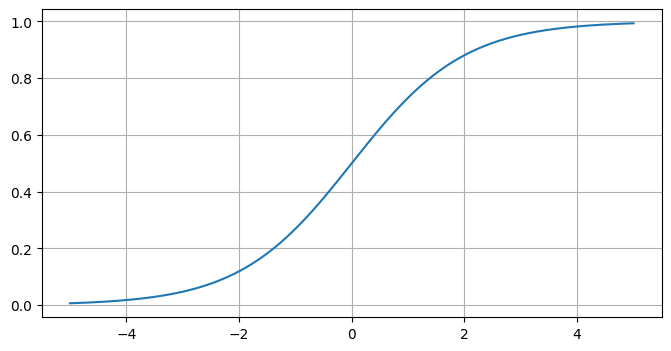

In [145]:
plot_activation_fn(sigmoid)

## Hyperbolic Tangent

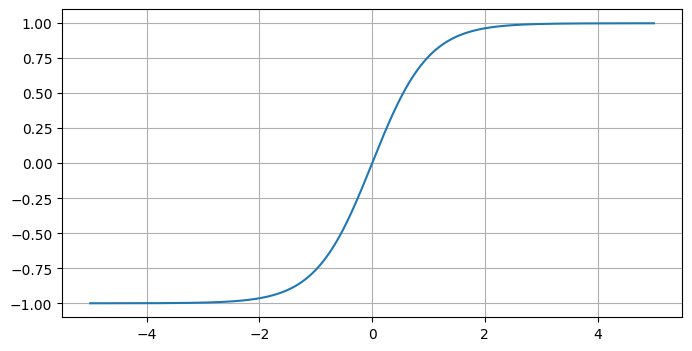

In [146]:
plot_activation_fn(np.tanh)

## ReLu(Rectified Linear Unit)

* 입력값이 양수이면 입력값 그대로 출력을 내보냄.
* 입력값이 음수이면 출력값을 0으로 만듦.
* 이미지를 처리할 때 좋은 성능을 낸다고 알려져 있음.

$
\text{ReLu}(x) =
\begin{cases}
x & \text{for } x \ge 0 \\
0 & \text{for } x \lt 0
\end{cases}
$

In [147]:
def relu(x):
  return np.maximum(x,0) # 둘중 비교해서 큰값 리턴

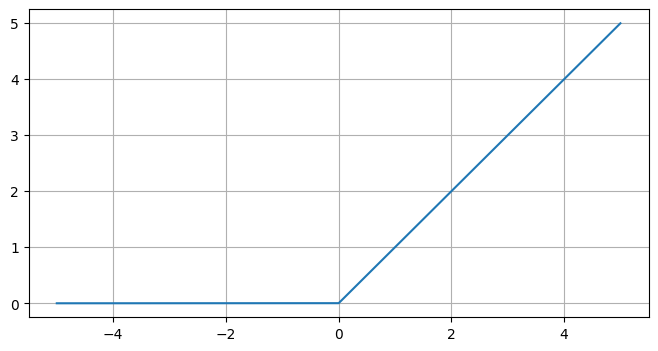

In [148]:
plot_activation_fn(relu)

## Leaky ReLu

$
\text {LeakyReLu}(x, \alpha) =
  \begin{cases}
    x & \text{for } x \ge 0 \\
    \alpha x & \text{for } x \lt 0,\alpha \ge 0
  \end{cases}
$

In [149]:
def leaky_relu(x,alpha=0.1):
  # 0<= alpha <= 1
  return np.maximum(x, alpha * x)

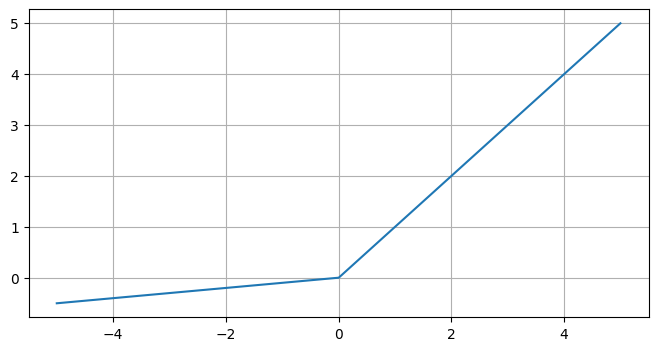

In [150]:
plot_activation_fn(leaky_relu)

## ELU(Exponential Linear Unit)

$
\text{ELU}(x, \alpha) =
  \begin{cases}
    x & \text{for } x \ge 0 \\
    \alpha (\exp(x) - 1) & \text{for } x \lt 0
  \end{cases}
$

In [151]:
def elu(x, alpha=1.0):
  return np.where(x>=0,x,alpha *(np.exp(x)-1))

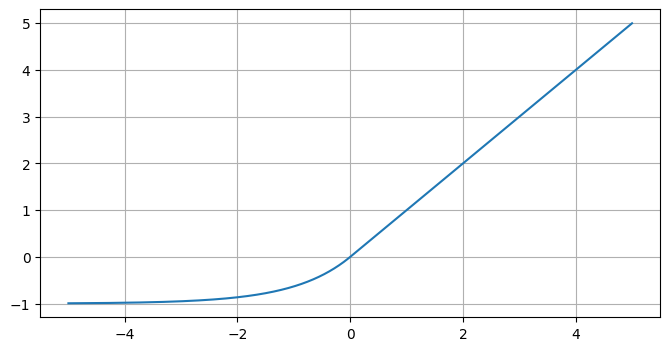

In [152]:
plot_activation_fn(elu)

은닉층에서 활성화 함수 선택: ELU > LeakyReLu > ReLu > tanh > sigmoid

# ReLu를 활성화 함수로 사용하는 은닉층

In [153]:
model =keras.Sequential() # 완전연결 신경망

In [154]:
model.add(keras.Input(shape=(28,28))) # 입력층

In [157]:
# Flatten 층: (28, 28)모양의 배열을 (784, )모양의 1차원 배열로 변환
model.add(keras.layers.Flatten())
# reshape 대안

In [158]:
# 은닉층: 100개의 unit들을 갖는, ReLu 활성화 함수를 사용하는 은닉층을 추가
model.add(keras.layers.Dense(units=100, activation='relu'))

In [159]:
# 출력층: 10개의 클래스로 분류하는 다중 클래스 분류 문제.
model.add(keras.layers.Dense(units=10, activation='softmax'))


In [161]:
model.summary()
# 784*100+100
# 100*10+10

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [163]:
# input flatten dense dense
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [164]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.9561 - sparse_categorical_accuracy: 0.7023
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.6196 - sparse_categorical_accuracy: 0.7948
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.5501 - sparse_categorical_accuracy: 0.8155
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.5148 - sparse_categorical_accuracy: 0.8251
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4913 - sparse_categorical_accuracy: 0.8314
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4745 - sparse_categorical_accuracy: 0.8364
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4611 - sparse_categorical_accuracy: 0.8408
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4498 - sparse_categorical_accuracy: 0.8446
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4401 - sparse_categorical_accuracy: 0.8472
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - 

In [165]:
model.evaluate(x=train_input, y=train_target) #훈련셋 평가

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.4237 - sparse_categorical_accuracy: 0.8527


[0.42373231053352356, 0.8526666760444641]

In [166]:
model.evaluate(x=val_input, y=val_target) # 검증셋 평가

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4223 - sparse_categorical_accuracy: 0.8547


[0.4222505986690521, 0.8547499775886536]

# Optimizer

**Optimizer(최적화 함수)**

* 손실함수를 최소화 시키는 과정에서 모델 파라미터(가중치)들을 최적화하는 알고리즘.
* 경사하강법(Gradient Descent): 손실함수의 기울기가 줄어드는 방향으로 모델 파라미터들을 최적화 시키는 알고리즘.

$
w_{next} = w_{init} - \text{learning_rate} \cdot \text {gradient}
$

* 아주 큰(깊은) 신경망인 경우는 모델 훈련에서 찾아야 하는 가중치들의 개수가 매우 많음.
* 모델 파라미터(가중치)들의 개수가 많을 수록 훈련 속도가 심각하게 느려질 수 있음.
* 훈련 속도를 빠르게 하는 방법:
  * 좋은 초기화 전략 사용하기
  * 좋은 활성화 함수 사용하기
  * 배치 정규화 사용하기
  * 사전 훈련된 네트워크(신경망)의 일부를 재사용
  * 일반적인 경사 하강법 대신 더 빠른 옵티마이저를 사용하기
* SGD(Stochastic Gradient Descent, 확률적 경사 하강법)의 파라미터 변경 - SGD 변종 옵티마이저
  * learning_rate(학습률) 파라미터를 변경
  * momentum(모멘텀) 파라미터 값을 0보다 큰 값으로 변경 - **모멘텀 최적화(momentum optimization)**  
  * nesterov(네스테로프) 파라미터를 True로 변경 - **네스테로프 가속 경사(NAG, Nesterov Accelerated Gradient)**
* 적응형 학습률(adaptive learning rate)을 사용한 옵티마이저
  * 학습할 때마다 학습률을 변화시킴.
  * RMSprop(Root Mean Squared Propagation): compile 메서드 optimizer 파라미터의 기본값.
  * Adam(Adaptive Momentum Estimation): 모멘텀 최적화 + RMSprop
  * Nadam: Adam + Nesterov
  * AdaGrad: Adam의 변종

## RMSprop 옵티마이저

In [167]:
def create_model(layers=None):
  # layers: keras.layers 객체(예:Dense)들의 배열/리스트. 깊은 신경망(deep neural network)을 만들기 위한 레이어.
  model = keras.Sequential() # 완전연결 신경망
  model.add(keras.Input(shape=(28,28))) # 입력층
  model.add(keras.layers.Flatten()) # Flatten layer: (28, 28) >> (784, )
  model.add(keras.layers.Dense(units=100, activation='elu')) # 첫번째 은닉층
  if layers: # 아구먼트로 전달된 은닉층들이 있으면
    for l in layers:
      model.add(l)
  model.add(keras.layers.Dense(units=10,activation='softmax'))

  return model

In [168]:
model1 =create_model()

In [169]:
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [171]:
model.fit(x=train_input,y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.4754 - sparse_categorical_accuracy: 0.8341
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4040 - sparse_categorical_accuracy: 0.8555
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3631 - sparse_categorical_accuracy: 0.8680
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3365 - sparse_categorical_accuracy: 0.8776
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3186 - sparse_categorical_accuracy: 0.8844
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3056 - sparse_categorical_accuracy: 0.8875
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2896 - sparse_categorical_accuracy: 0.8948
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2811 - sparse_categorical_accuracy: 0.8967
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2722 - sparse_categorical_accuracy: 0.9003
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - 

## Adam 파라미터:

* learning_rate: 학습률
* beta_1: 모멘텀
* beta_2: RMSprop의 rho와 비슷

In [174]:
model2=create_model()

In [180]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [175]:
model2.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [176]:
model2.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.5467 - sparse_categorical_accuracy: 0.8091
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.4110 - sparse_categorical_accuracy: 0.8518
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.3728 - sparse_categorical_accuracy: 0.8656
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.3486 - sparse_categorical_accuracy: 0.8732
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.3238 - sparse_categorical_accuracy: 0.8801
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.3112 - sparse_categorical_accuracy: 0.8865
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2957 - sparse_categorical_accuracy: 0.8909
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2855 - sparse_categorical_accuracy: 0.8939
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2742 - sparse_categorical_accuracy: 0.8994
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step -

In [178]:
model2.evaluate(x=train_input,y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2502 - sparse_categorical_accuracy: 0.9066


[0.2501867413520813, 0.9066458344459534]

In [179]:
model2.evaluate(x=val_input,y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3142 - sparse_categorical_accuracy: 0.8861


[0.3141660690307617, 0.8860833048820496]

# 모델의 저장과 복원

`History`객체: 신경망 모델을 훈련(fit)시키는 과정(각각의 epochs)의 기록을 담고 있는 객체. `fit`메서드의 리턴 타입.

In [181]:
model=create_model()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [182]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [184]:
result=model.fit(x=train_input,y=train_target,batch_size=64,epochs=10,
                 validation_data=[val_input, val_target])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.5667 - sparse_categorical_accuracy: 0.8001 - val_loss: 0.4139 - val_sparse_categorical_accuracy: 0.8552
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4170 - sparse_categorical_accuracy: 0.8500 - val_loss: 0.3735 - val_sparse_categorical_accuracy: 0.8648
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3750 - sparse_categorical_accuracy: 0.8638 - val_loss: 0.3608 - val_sparse_categorical_accuracy: 0.8702
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3507 - sparse_categorical_accuracy: 0.8705 - val_loss: 0.3508 - val_sparse_categorical_accuracy: 0.8758
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3324 - sparse_categorical_accuracy: 0.8775 - val_loss: 0.3437 - val_sparse_categorical_accuracy: 0.8783
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3176 - sparse_categorical_accuracy: 0.8840 - val_loss: 0.3346 - val_sparse_categorical_accuracy: 0.8819
Ep

In [185]:
print(type(result))

<class 'keras.src.callbacks.history.History'>


In [186]:
history=result.history
history #> dict 타입 객체 - 훈련 손실, 훈련 정확도, 검증 손실, 검증 정확도

{'loss': [0.566670835018158,
  0.4170142710208893,
  0.37497928738594055,
  0.3507232666015625,
  0.33236008882522583,
  0.31763115525245667,
  0.3043461740016937,
  0.29316017031669617,
  0.28339332342147827,
  0.27527526021003723],
 'sparse_categorical_accuracy': [0.8000624775886536,
  0.8500416874885559,
  0.8638333082199097,
  0.870520830154419,
  0.8774583339691162,
  0.8840416669845581,
  0.8881250023841858,
  0.8917916417121887,
  0.8957083225250244,
  0.89822918176651],
 'val_loss': [0.41390058398246765,
  0.3734719753265381,
  0.36077892780303955,
  0.3508411943912506,
  0.34369000792503357,
  0.3345690667629242,
  0.3294864594936371,
  0.3376483619213104,
  0.31528720259666443,
  0.3082576394081116],
 'val_sparse_categorical_accuracy': [0.8551666736602783,
  0.8648333549499512,
  0.8701666593551636,
  0.8758333325386047,
  0.878333330154419,
  0.8819166421890259,
  0.8801666498184204,
  0.8801666498184204,
  0.8883333206176758,
  0.890250027179718]}

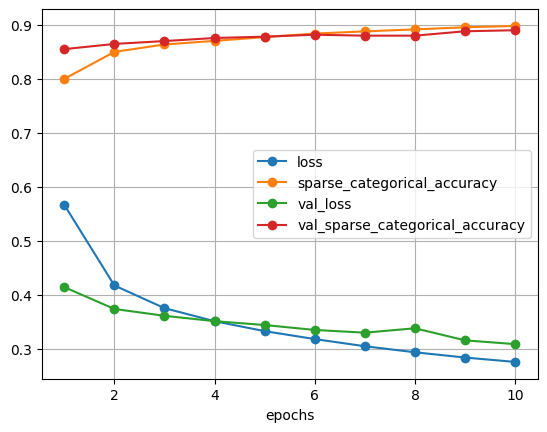

In [189]:
epochs= np.arange(1,11)
for k,v in history.items(): #dict에서 items를 해야 key & value를 뽑을수있다
  plt.plot(epochs, v, 'o-', label=k)
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.show()

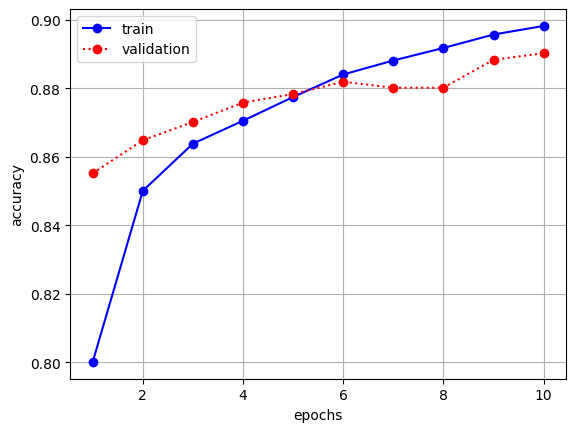

In [190]:
# 에포크에 따른 정확도 변화
plt.plot(epochs, history['sparse_categorical_accuracy'], 'bo-',label='train')
plt.plot(epochs, history['val_sparse_categorical_accuracy'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

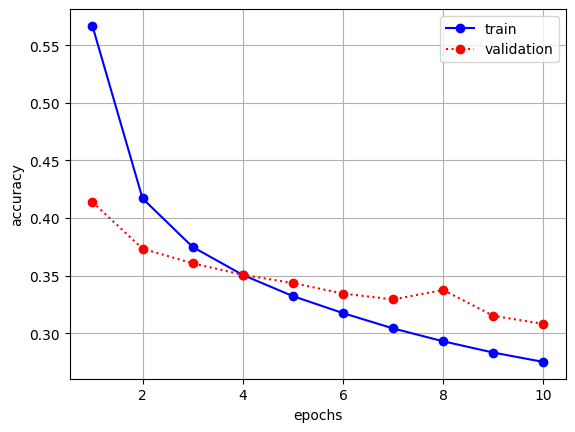

In [191]:
# 검증셋에서의 점수가 2번 3번 떨어지면 바로 그 전 점수가 최적의 점수라는 말이다 이말이야
# epochs에 따른 손실 변화
plt.plot(epochs, history['loss'], 'bo-',label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

## Adam 옵티마이저를 사용, epochs 20회, 훈련/검증 셋의 손실 그래프

In [212]:
# model2.compile(optimizer=keras.optimizers.Adam(),
#               loss=keras.losses.sparse_categorical_crossentropy,
#               metrics=[keras.metrics.sparse_categorical_accuracy])
# result2=model2.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
#                  validation_data=[val_input, val_target])
model = create_model()
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result = model.fit(x=train_input, y=train_target, batch_size=64, epochs=20,
                   validation_data=[val_input, val_target])


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.5458 - sparse_categorical_accuracy: 0.8108 - val_loss: 0.4346 - val_sparse_categorical_accuracy: 0.8466
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4117 - sparse_categorical_accuracy: 0.8524 - val_loss: 0.3895 - val_sparse_categorical_accuracy: 0.8594
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.3732 - sparse_categorical_accuracy: 0.8646 - val_loss: 0.3542 - val_sparse_categorical_accuracy: 0.8730
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.3461 - sparse_categorical_accuracy: 0.8736 - val_loss: 0.3487 - val_sparse_categorical_accuracy: 0.8751
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.3255 - sparse_categorical_accuracy: 0.8801 - val_loss: 0.3547 - val_sparse_categorical_accuracy: 0.8725
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3104 - sparse_categorical_accuracy: 0.8869 - val_loss: 0.3313 - val_sparse_categorical_accuracy: 0.8838
Ep

In [213]:
history=result.history
history

{'loss': [0.5457764267921448,
  0.41167378425598145,
  0.3732392191886902,
  0.34607255458831787,
  0.32549723982810974,
  0.3103615343570709,
  0.29685547947883606,
  0.28522494435310364,
  0.27442070841789246,
  0.2650125324726105,
  0.25634634494781494,
  0.24495089054107666,
  0.2395162135362625,
  0.23274308443069458,
  0.2286165952682495,
  0.22002272307872772,
  0.21517029404640198,
  0.20962361991405487,
  0.20555731654167175,
  0.19865836203098297],
 'sparse_categorical_accuracy': [0.8108124732971191,
  0.8524166941642761,
  0.8646041750907898,
  0.8735625147819519,
  0.8800625205039978,
  0.8868541717529297,
  0.8894791603088379,
  0.8947499990463257,
  0.8980416655540466,
  0.9010624885559082,
  0.9040625095367432,
  0.9090416431427002,
  0.9108750224113464,
  0.9146249890327454,
  0.9151874780654907,
  0.9189375042915344,
  0.9192708134651184,
  0.92208331823349,
  0.9227499961853027,
  0.9262291789054871],
 'val_loss': [0.4345845878124237,
  0.38947683572769165,
  0.354205

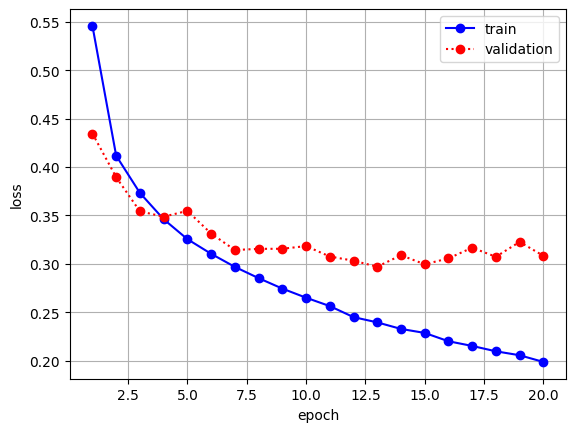

In [216]:
# # epochs에 따른 손실 변화
# plt.plot(epochs, history['loss'], 'bo-',label='train')
# plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
# plt.legend()
# plt.grid()
# plt.xlabel('epochs')
# plt.ylabel('accuracy')
# plt.show()
history = result.history
epochs = np.arange(1, 21)
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [218]:
model3=create_model()
model3.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result3=model3.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
                 validation_data=[val_input, val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.5619 - sparse_categorical_accuracy: 0.8030 - val_loss: 0.4175 - val_sparse_categorical_accuracy: 0.8522
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4146 - sparse_categorical_accuracy: 0.8511 - val_loss: 0.3827 - val_sparse_categorical_accuracy: 0.8623
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3755 - sparse_categorical_accuracy: 0.8630 - val_loss: 0.3521 - val_sparse_categorical_accuracy: 0.8761
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3490 - sparse_categorical_accuracy: 0.8723 - val_loss: 0.3380 - val_sparse_categorical_accuracy: 0.8801
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3310 - sparse_categorical_accuracy: 0.8780 - val_loss: 0.3426 - val_sparse_categorical_accuracy: 0.8767
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3149 - sparse_categorical_accuracy: 0.8848 - val_loss: 0.3276 - val_sparse_categorical_accuracy: 0.8842
Epo

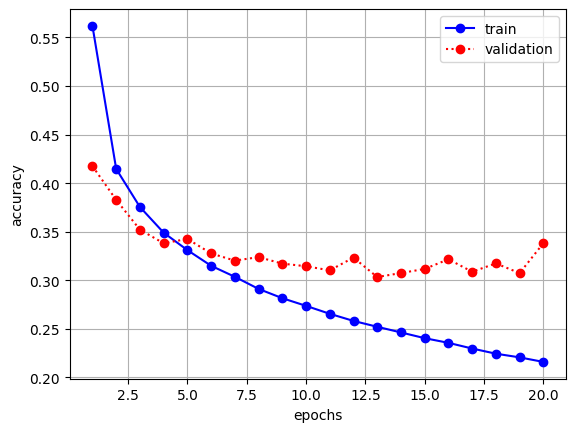

In [219]:
# epochs에 따른 손실 변화
history = result3.history
epochs = np.arange(1, 21)
plt.plot(epochs, history['loss'], 'bo-',label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

# Dropout

* 모델의 과대적합을 줄이는 방법
* 훈련 과정(epoch)에서 일부 유닛(unit)의 출력을 0으로 만드는 것.
    * 다음 계층(layer)로 출력값을 전달하지 않음.
* 각 epoch마다 출력을 0으로 만드는 유닛은 무작위로 선택.
    

In [221]:
# 은닉층 뒤에 30% 비율로 출력을 0으로 만드는 Dropout 계층을 추가
model = create_model(layers=[keras.layers.Dropout(rate=0.3)])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [225]:
model2.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [227]:
result=model2.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
                  validation_data=[val_input,val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.1044 - sparse_categorical_accuracy: 0.9611 - val_loss: 0.4162 - val_sparse_categorical_accuracy: 0.8951
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0986 - sparse_categorical_accuracy: 0.9638 - val_loss: 0.4023 - val_sparse_categorical_accuracy: 0.8984
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0983 - sparse_categorical_accuracy: 0.9636 - val_loss: 0.4132 - val_sparse_categorical_accuracy: 0.8972
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0972 - sparse_categorical_accuracy: 0.9641 - val_loss: 0.3995 - val_sparse_categorical_accuracy: 0.9007
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0924 - sparse_categorical_accuracy: 0.9661 - val_loss: 0.4148 - val_sparse_categorical_accuracy: 0.8980
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0927 - sparse_categorical_accuracy: 0.9659 - val_loss: 0.4150 - val_sparse_categorical_accuracy: 0.899

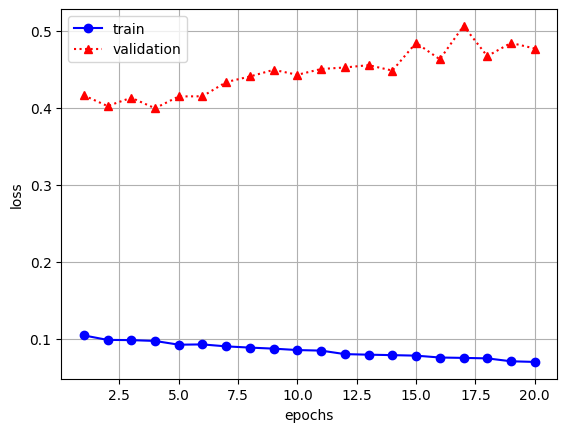

In [228]:
history=result.history
epochs=np.arange(1,21)
plt.plot(epochs,history['loss'],'bo-',label='train')
plt.plot(epochs,history['val_loss'],'r^:',label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
